In [14]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions 
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

In [15]:
dataGen = ImageDataGenerator(rescale=1./255)
imgGen = dataGen.flow_from_directory('./cat_dog', target_size=(100,100))
imgGen

Found 20 images belonging to 2 classes.


In [16]:
x_data, y_data = next(imgGen) # next 시 100개를 가져오는게 아니라 32개를 가져 옴. 

In [17]:
x_data.shape

(20, 100, 100, 3)

In [18]:
y_data.shape

(20, 2)

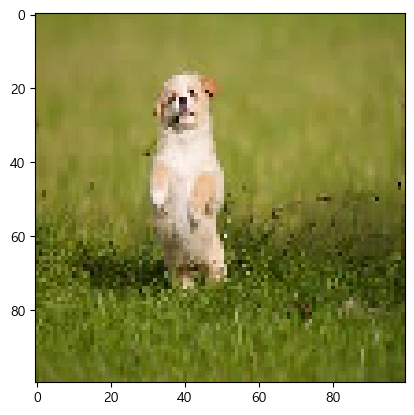

In [19]:
plt.imshow(x_data[0])
plt.show()

In [20]:
y_data[0]

array([0., 1.], dtype=float32)

In [21]:
imgGen.class_indices

{'cat': 0, 'dog': 1}

---

딥러닝 학습

In [22]:
# CNN 적용 전
model = Sequential()
model.add( Flatten( input_shape=(100,100,3) ) )
model.add( Dense( units=64, activation='relu')) 
model.add( Dense( units=32, activation='relu')) 
model.add( Dense( units=2, activation='softmax')) 
model.compile( loss='categorical_crossentropy', optimizer='adam',metrics=['acc'])
model.fit(imgGen, epochs=50) # 
# model.fit(x_data/255, y_data, epochs=50)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - acc: 0.4000 - loss: 0.7130
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.5000 - loss: 1.3861
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - acc: 0.5000 - loss: 4.4892
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7500 - loss: 0.5176
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.5000 - loss: 5.4784
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.5000 - loss: 2.9270
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.9000 - loss: 0.5875
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - acc: 0.7500 - loss: 0.6833
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.8000 - loss: 0.6143
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.8000 - loss: 0.3980
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.8500 - loss: 0.5366
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.8500 - loss: 0.2285
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7

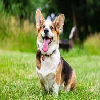

In [23]:
testImg = load_img('cat_dog/dog/dog2.jpg', target_size=(100,100))
testImg

In [ ]:
imgArr = img_to_array(testImg)/255 # 정규화를 위해 255로 나눠 줌
imgArr

array([[[0.2509804 , 0.41568628, 0.16470589],
        [0.23529412, 0.36862746, 0.07843138],
        [0.24705882, 0.34509805, 0.12156863],
        ...,
        [0.07843138, 0.16862746, 0.05490196],
        [0.07450981, 0.1764706 , 0.03921569],
        [0.06666667, 0.10980392, 0.04705882]],

       [[0.25882354, 0.42745098, 0.15686275],
        [0.29803923, 0.44313726, 0.14117648],
        [0.3137255 , 0.41568628, 0.1764706 ],
        ...,
        [0.08627451, 0.1764706 , 0.0627451 ],
        [0.10980392, 0.20392157, 0.07058824],
        [0.10980392, 0.16862746, 0.09411765]],

       [[0.2784314 , 0.45882353, 0.16470589],
        [0.3647059 , 0.5176471 , 0.2       ],
        [0.35686275, 0.4745098 , 0.2       ],
        ...,
        [0.10196079, 0.18039216, 0.07450981],
        [0.12941177, 0.22352941, 0.09019608],
        [0.13725491, 0.20784314, 0.11372549]],

       ...,

       [[0.3529412 , 0.5058824 , 0.04705882],
        [0.42745098, 0.59607846, 0.13333334],
        [0.36078432, 0

In [25]:
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1) # {'cat': 0, 'dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([1])

---

### CNN 학습

In [ ]:
model = Sequential()
# 특징추출기 
model.add(Conv2D(32, kernel_size=(3,3), strides=1,
                input_shape=(100,100,3),activation='relu', padding='same')) 
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
# 분류기
model.add(Flatten())
model.add(Dense(units=64, activation='relu')) 
model.add(Dense(units=2, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
# model.summary() 파라미터수 확인
model.fit(imgGen, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - acc: 0.4500 - loss: 0.7050
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - acc: 0.5000 - loss: 2.9049
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - acc: 0.5000 - loss: 7.7612
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - acc: 0.5000 - loss: 3.7695
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - acc: 0.5500 - loss: 0.7170
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - acc: 0.5500 - loss: 0.6466
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - acc: 0.5000 - loss: 0.9692
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - acc: 0.5000 - loss: 0.7356
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - acc: 0.6000 - loss: 0.5237
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.9000 - loss: 0.3644


In [31]:
img = load_img('cat1.jpg', target_size=(100,100))
carr = img_to_array(img)/255
model.predict(carr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([0])

In [ ]:
imgGen.class_indices # 모델이 사용하는 실제 정답 숫자 기준표

{'cat': 0, 'dog': 1}